In [11]:
#import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean visual style for all our plots
# seaborn styles make plots look more professional with minimal effort
sns.set_style('whitegrid')
sns.set_palette('deep')

#load NHTS data for analysis 
NHTS_data = pd.read_csv("NHTS(in).csv")

#load NGSIM data
ngsim_data = pd.read_csv('NGSIM(in).csv')

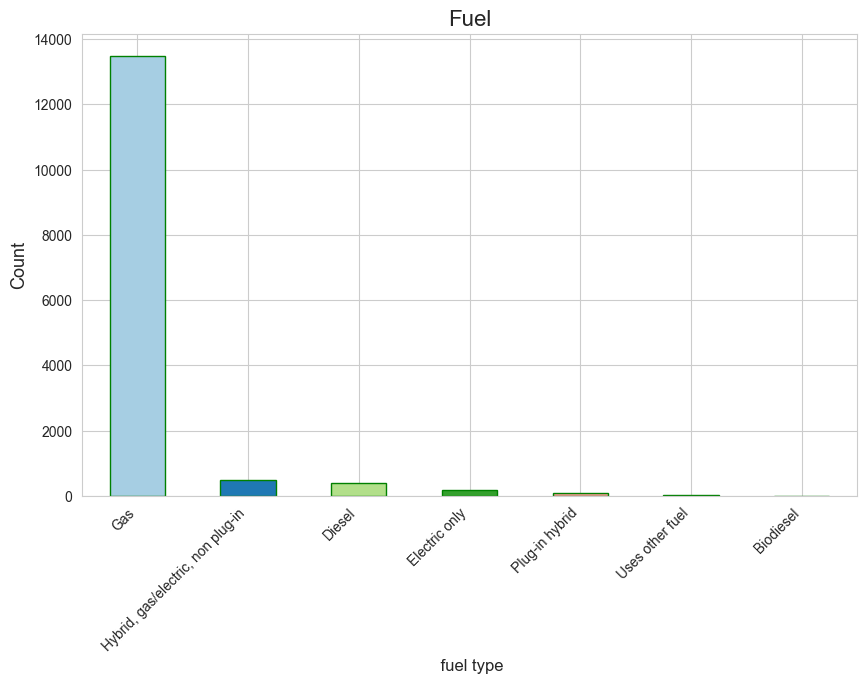

In [12]:
#  bar chart to show count of vehicles by fuel type

## count the number of vehicles by fuel type
fuel_counts = NHTS_data['fuel_type'].value_counts().dropna()
plt.figure(figsize = (10,6))

## create the bar plot

fuel_counts.plot(kind = 'bar', edgecolor = "green", color = sns.color_palette('Paired', len(fuel_counts)))
## Step 3: add labels and customization

plt.xticks(rotation=45, ha='right')
plt.xlabel(' fuel type', fontsize=12)
plt.ylabel('Count', fontsize=13)
plt.title("Fuel", fontsize=16)


## show the plot
plt.show()

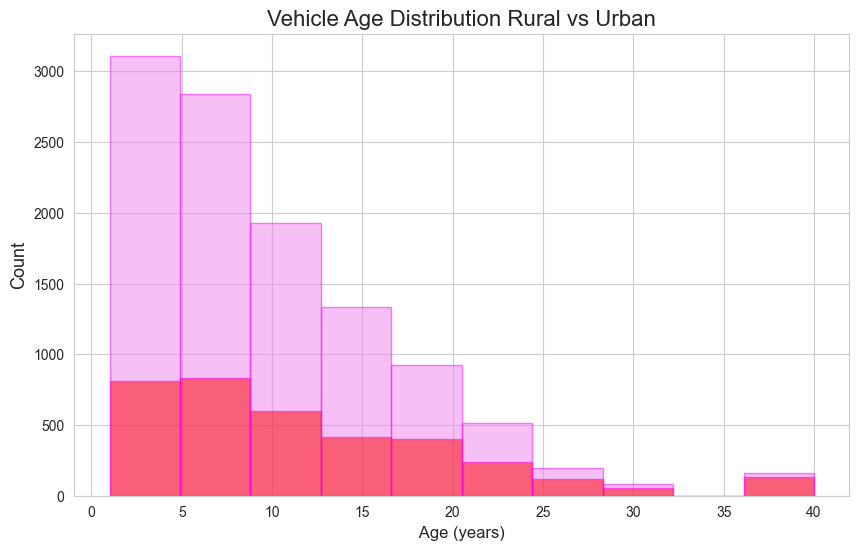

In [13]:
# Create overlapping histograms for Urban vs Rural vehicle ages
# We need to filter the data first, then plot each group separately

## Step 1: tell Python you are making a figure
plt.figure(figsize=(10,6))

## Step 2: filter and plot Urban vehicle ages
# hint: use nhts_data[nhts_data['household_location'] == 'Urban']['vehicle_age']
# use the alpha argument to make bars semi-transparent (e.g., alpha=0.5)
urban_ages = NHTS_data[NHTS_data['household_location']== 'Urban']['vehicle_age']
rural_ages = NHTS_data[NHTS_data['household_location']== 'Rural']['vehicle_age']
plt.hist(urban_ages, bins = 10, color = 'violet', edgecolor = 'magenta', alpha = 0.5)

## Step 3: filter and plot Rural vehicle ages on the same figure
plt.hist(rural_ages, bins = 10, color = 'red', edgecolor = 'magenta', alpha = 0.5)

## Step 4: add labels, title, and legend
plt.xlabel(' Age (years) ', fontsize=12)
plt.ylabel('Count', fontsize=13)
plt.title("Vehicle Age Distribution Rural vs Urban", fontsize=16)

plt.show()


<Figure size 1400x800 with 0 Axes>

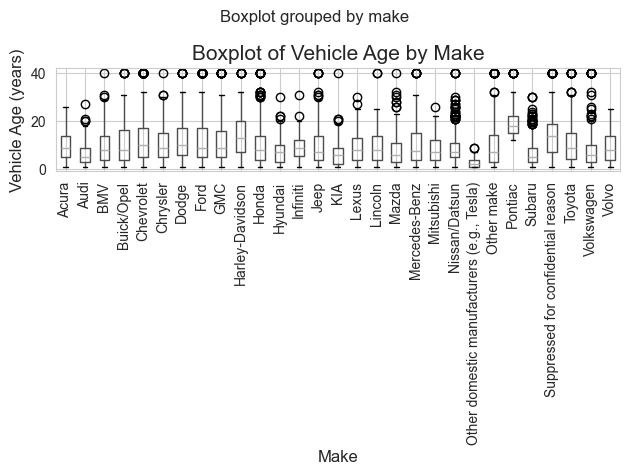

In [14]:
#creating a box plot for vehicle age by make

# tell Python you are making a figure and what size you want the figure to be
plt.figure(figsize = (14,8))



## call the type of plot and tell the function what variables you want to plot
boxplot = NHTS_data.boxplot(column = 'vehicle_age', by = 'make' )


## add customization to the plot

### this line rotates your labels on the x-axis by 90 so they are easy to read
plt.xticks(rotation=90)

### the next two lines create your axis labels
plt.xlabel('Make', fontsize=12)
plt.ylabel('Vehicle Age (years)', fontsize=12)
           
### this line gives your plot a title
plt.title('Boxplot of Vehicle Age by Make', fontsize=15)

## tell python to show the plot
plt.tight_layout()

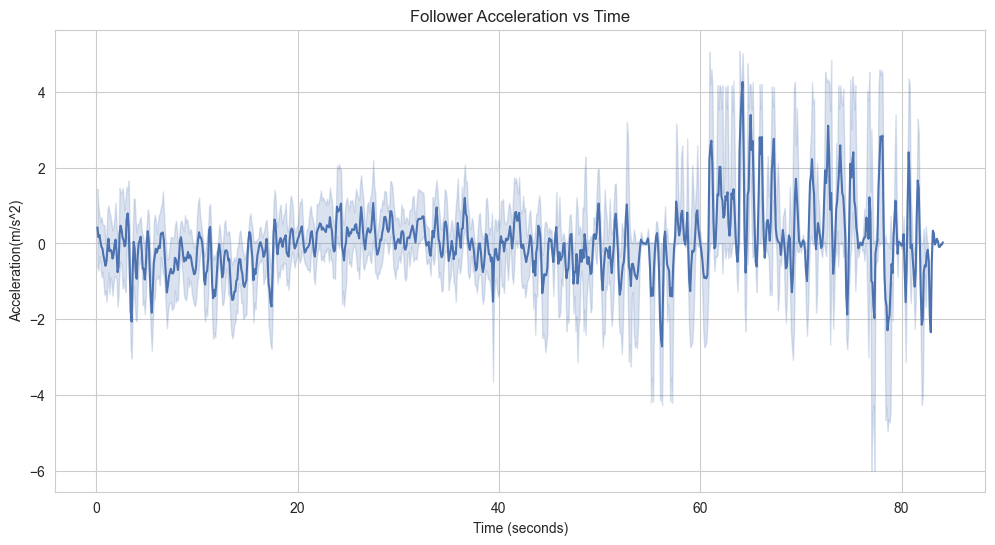

In [15]:
### Plotting Acceleration vs Time 
#time series plot 1
plt.figure(figsize = (12,6))

# We are interested in analyzing the acceleration profile of the follower vehicles (follower_acc(m/s^2)) as function of time. Follow the steps we have learned from previous lab to do so. 
# hint we need to use the sns.lineplot 

# Step 1: tell python that you want to plot and assign a size 

# Step 2: use sns.lineplot to create a time series plot of Time (x-axis) and follower_acc(m/s^2) (y-axis)
sns.lineplot(x = ngsim_data['Time'], y = ngsim_data['leader_acc(m/s^2)'])
# Step 3: add customizations
plt.xlabel('Time (seconds)')
plt.ylabel('Acceleration(m/s^2)')
plt.title('Follower Acceleration vs Time')
plt.show()


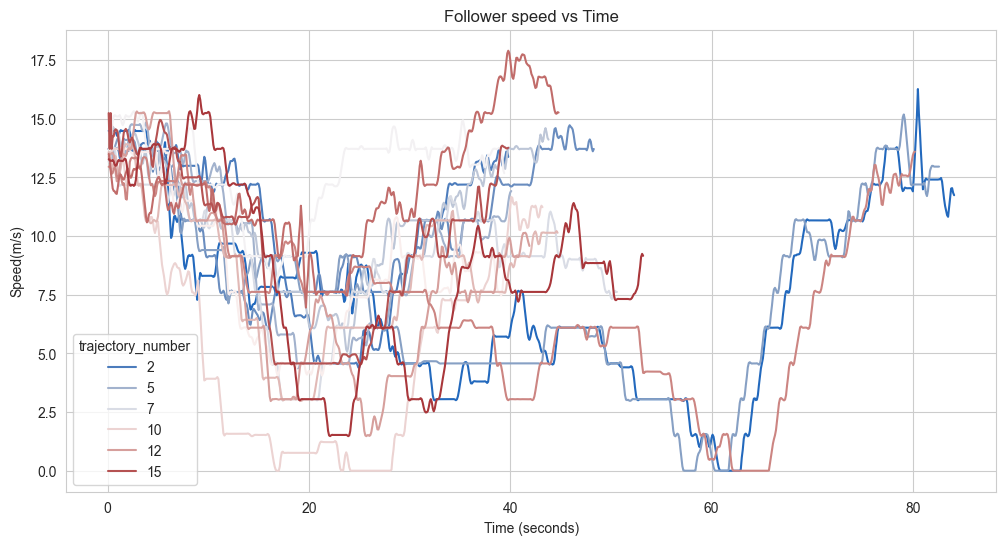

In [16]:
### Plotting Speed vs Time
#time-series plot 2
plt.figure(figsize = (12,6))

#utilize same steps as for time-series plot 1


sns.lineplot(data = ngsim_data ,x = 'Time', y = 'follower_speed(m/s)', hue = 'trajectory_number', palette = "vlag")


plt.xlabel('Time (seconds)')
plt.ylabel('Speed(m/s)')
plt.title('Follower speed vs Time')
plt.show()
plt.show()

Simulation Study

In [17]:
# Define the IDM acceleration function
# The function should take the following inputs:
#   v      : current speed of the follower vehicle (m/s)
#   s      : current gap distance between leader and follower (m)
#   delta_v : speed difference = follower speed - leader speed (m/s)
#   v0     : desired velocity (m/s)
#   s0     : minimum spacing (m)
#   T      : desired time headway (s)
#   a      : maximum acceleration (m/s^2)
#   b      : comfortable deceleration (m/s^2)
#   delta  : acceleration exponent

def idm_acceleration(test_v, test_s, delta_v, v0, s0, T, a, b, delta):
    # Step 1: Calculate the desired minimum gap s_star
    s_star = s0 + test_v * T + (test_v * delta_v) / (2 * np.sqrt(a * b))
    
    
    
    # Make sure s_star is not negative
    s_star = max(s_star, s0)
    
    # Step 2: Calculate the acceleration using the IDM equation
    acceleration = a * (1 - (test_v/v0)**delta - (s_star/test_s)**2)
    
    
    
    return acceleration

In [19]:
#setting up simulation
# Select a trajectory pair
trajectory_number = 2
data_subset = ngsim_data[ngsim_data['trajectory_number'] == trajectory_number].reset_index(drop = True)

# Extract the leader's position and speed over time
time_data = data_subset['Time'].values
leader_position = data_subset['leader_position(m)'].values
leader_speed = data_subset['leader_speed(m/s)'].values

# Identifying the time step in our data
dt = 0.1 # seconds
#print(time_data)

In [24]:
# Set the IDM parameters
v0 = 30    # desired velocity (m/s)
s0 = 2     # minimum spacing (m)
T = 1.5    # desired time headway (s)
a  = 1.0    # maximum acceleration (m/s^2)  
b = 1.5    # comfortable deceleration (m/s^2)
delta = 4  # acceleration exponent

# Initialize arrays to store simulation results
n_steps = len(time_data)         # number of simulation steps we will take, which will be equal to the length of the trajectory data
sim_position = np.zeros(n_steps) # simulated follower position; we will create a vector with all zeroes  as a start
sim_speed = np.zeros(n_steps)       # simulated follower speed; we will create a vector with all zeroes  as a start
sim_acc = np.zeros(n_steps)           # simulated follower acceleration; we will create a vector with all zeroes  as a start

# Start at the real follower's initial state
sim_position[0] = data_subset['follower_position(m)'].values[0]        #this makes the starting value [0] same as the follower vehicle position
sim_speed[0] = data_subset['follower_speed(m/s)'].values[0]        #this makes the starting value [0] same as the follower vehicle speed

In [25]:
# Run the IDM simulation
# We loop through each time step and calculate:
#   1. The gap between the leader and follower
#   2. The speed difference between the two vehicles
#   3. The IDM acceleration
#   4. The updated speed using: new_speed = old_speed + acceleration * dt
#   5. The updated position using: new_position = old_position + speed * dt

for i in range(n_steps - 1): # we do -1 since the first element is known (remember the step above) 

    # Step 1 & 2: Calculate the gap and speed difference at this time step
    gap = max(leader_position[i]- sim_position[i], 1.1)
    delta_v = sim_speed[i] - leader_speed [i]

    # Step 3: Use the IDM function to calculate acceleration
    sim_acc[i] = idm_acceleration(sim_speed[i], gap, delta_v, v0, s0, T, a, b, delta)

    # Step 4 & 5: Update speed and position for the next time step
    sim_speed[i+1] = max(sim_speed[i] + sim_acc[i]*dt, 0)
    sim_position[i+1] = sim_position[i] + sim_speed[i]*dt
    

print("Simulation complete!")

Simulation complete!


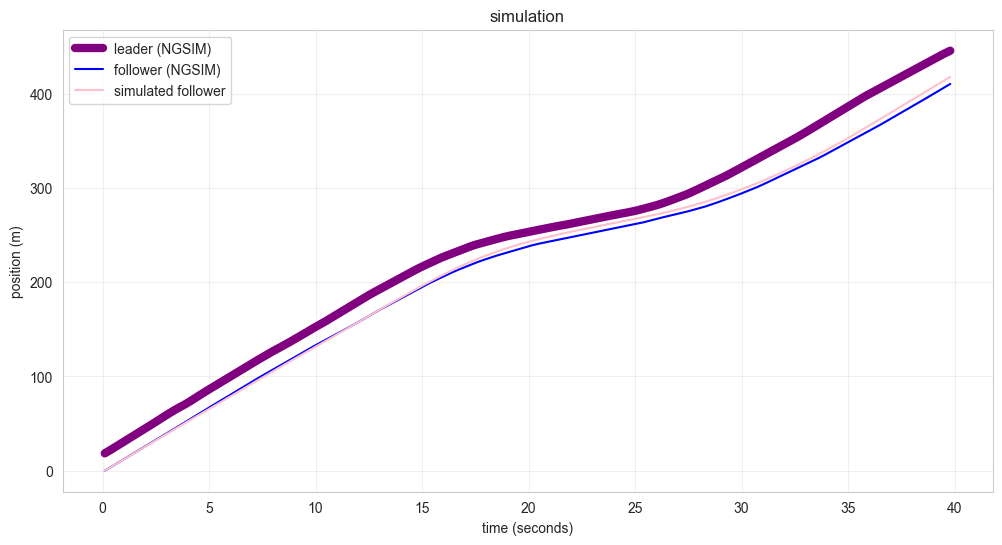

In [26]:
#visulize simulation
#Plot 1: Position vs Time — Comparing leader, real follower, and simulated follower
plt.figure(figsize = (12,6))
plt.plot(time_data, leader_position, label = 'leader (NGSIM)', color = "purple", linewidth = 6)
plt.plot(time_data,data_subset['follower_position(m)'].values, label = 'follower (NGSIM)', color = "blue")
plt.plot(time_data, sim_position, label = 'simulated follower', color = "pink")
plt.xlabel('time (seconds)')
plt.ylabel('position (m)')
plt.legend()
plt.grid(True, alpha = 0.3)
plt.title('simulation')
plt.show()
